In [138]:
import torch
import re
import torch.nn.functional as F
import torch.nn as nn

In [10]:
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(device)

mps


In [3]:
stories=[]
with open('TinyStories-train.txt','r') as f:
    story=''
    count=0
    for line in f:
        story += line
        if line.rstrip() == '<|endoftext|>':
            stories.append(story)
            story=''
            count+=1
            if count == 50000:
                break
len(stories)

50000

In [5]:
vocab = set(['<|startoftext|>'])
word_level_stories = []
for text in stories:
    pattern = r"<\|.*?\|>|\n|[a-zA-Z]+|[.,!?\"']"
    tokens = re.findall(pattern, text)
    vocab.update(tokens)
    word_level_stories.append(tokens)
vocab = list(sorted(vocab))
vocab_size=len(vocab)
start = next(i for i, word in enumerate(vocab) if word == '<|startoftext|>')
end = next(i for i, word in enumerate(vocab) if word == '<|endoftext|>')
vocab_size,start,end,len(word_level_stories)

(16490, 7, 6, 50000)

2 1110 218


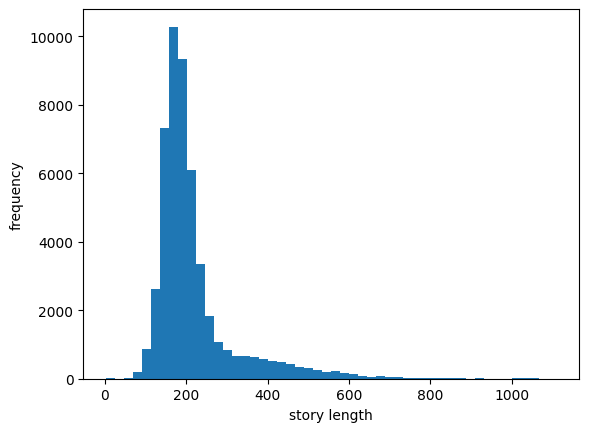

In [129]:
lengths = [len(story) for story in word_level_stories]
print(min(lengths), max(lengths), sum(lengths)//len(lengths))
import matplotlib.pyplot as plt
plt.hist(lengths, bins=50)
plt.xlabel('story length')
plt.ylabel('frequency')
plt.show()

In [6]:
word_to_i = { word:i for i,word in enumerate(vocab)}
i_to_word = { i:word for i,word in enumerate(vocab)}

In [130]:
context_len = 256

def build_dataset(stories):
    xs, ys = [], []
    for words in stories:
        context = [start] + [word_to_i[word] for word in words[:-1]]
        out = [word_to_i[word] for word in words[:-1]] + [end]
        
        # truncate
        context = context[:context_len]
        out = out[:context_len]
        
        # pad
        context += [-1] * (context_len - len(context))
        out += [-1] * (context_len - len(out))
        
        xs.append(torch.tensor(context).to(device))
        ys.append(torch.tensor(out).to(device))
    
    return torch.stack(xs).to(device), torch.stack(ys).to(device)

import random
random.seed(42)
random.shuffle(word_level_stories)
n1 = int(0.8*len(word_level_stories))
n2 = int(0.9*len(word_level_stories))

Xtr,  Ytr  = build_dataset(word_level_stories[:n1])     # 80%
Xdev, Ydev = build_dataset(word_level_stories[n1:n2])   # 10%
Xte,  Yte  = build_dataset(word_level_stories[n2:])     # 10%

Xtr.shape,Ytr.shape, Xdev.shape,Ydev.shape, Xte.shape,Yte.shape

(torch.Size([40000, 256]),
 torch.Size([40000, 256]),
 torch.Size([5000, 256]),
 torch.Size([5000, 256]),
 torch.Size([5000, 256]),
 torch.Size([5000, 256]))

In [168]:
n_embed = 32
n_hidd = 256
batch_size = 32

In [132]:
g = torch.Generator().manual_seed(2147483647)
#embedding
C = torch.randn((vocab_size,n_embed),generator=g).to(device)
#attention
Wa = torch.randn((context_len,context_len),generator=g).to(device)*0.1
#first layer
W1 = torch.randn((context_len,n_hidd),generator=g).to(device)*0.1
b1 = torch.randn((n_hidd),generator=g).to(device)*0.1
#second layer
W2 = torch.randn((n_hidd,n_hidd),generator=g).to(device)*0.1
b2 = torch.randn((n_hidd),generator=g).to(device)*0.1
#logits layer
W3 = torch.randn((n_hidd,vocab_size),generator=g).to(device)*0.1
b3 = torch.randn((vocab_size),generator=g).to(device) * 0
parameters = [C, Wa, W1, b1, W2, b2, W3, b3]
for p in parameters:
    p.requires_grad = True

In [152]:
for i in range(1):
    idx = torch.randint(0, Xtr.shape[0], (batch_size,))
    xi = Xtr[idx].to(device)  # (32, context_len)
    yi = Ytr[idx].to(device)  # (32, context_len)
    
    mask = (xi == -1).to(device)
    E = C[xi.clamp(min=0)]
    E = E.masked_fill(mask.unsqueeze(-1),0.0)
    
    seq_len = xi.shape[1]
    causal_mask = torch.ones(seq_len, seq_len).tril(diagonal=0)  # lower triangle, diagonal excluded
    causal_mask = (causal_mask == 0).to(device)  # positions to mask out (upper tri + diagonal)
    
    apre = E @ E.transpose(-1, -2)
    apre_soft = Wa @ apre
    apre_soft = apre_soft.masked_fill(causal_mask, float('-inf'))
    
    #attention
    a = F.softmax(apre_soft, dim=1)
    print(a.shape)
    #first layer
    x1 = torch.relu((a @ W1) + b1)
    
    #second layer
    x2 = torch.relu((x1 @ W2) + b2)
    
    #logits layer
    logits = ((x2 @ W3) + b3).to(device)
    
    loss = F.cross_entropy(
        logits.view(-1, vocab_size),  # (batch*context_len, vocab_size)
        yi.view(-1),                   # (batch*context_len,)
        ignore_index=-1,
        reduction='mean'
    )
    
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += (-0.5) * p.grad
    print('loss: ',loss.item())

torch.Size([32, 256, 256])
loss:  8.637447357177734


In [139]:
#------------------------------------- USING nn MODULE ------------------------------------------------#

In [169]:
class AttentionModel(nn.Module):
    def __init__(self, n_embed, n_hidd, context_len, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size,n_embed,-1)
        self.Wa = nn.Parameter(torch.randn((context_len,context_len)) * 0.01)
        self.first_linear = nn.Linear(n_embed,n_hidd)
        self.le_relu1 = nn.LeakyReLU(0.01)
        self.second_linear = nn.Linear(n_hidd,n_hidd)
        self.le_relu2 = nn.LeakyReLU(0.01)
        self.logits_linear = nn.Linear(n_hidd,vocab_size)
        
    def forward(self, x):
        pad_mask = (x == -1)
        x = self.embedding(x)  # (batch, context_len, n_embed)
        
        attn = x @ x.transpose(-1, -2)  # (batch, context_len, context_len)
        attn = attn @ self.Wa
        
        # causal mask
        seq_len = x.shape[1]
        causal_mask = torch.ones(seq_len, seq_len).tril(diagonal=0)
        causal_mask = (causal_mask == 0).to(x.device)
        attn = attn.masked_fill(causal_mask, float('-inf'))
        
        # pad mask
        pad_mask = pad_mask.unsqueeze(1).expand(-1, seq_len, seq_len).to(x.device)
        attn = attn.masked_fill(pad_mask, float('-inf'))
        
        attn = F.softmax(attn, dim=-1)
        x = attn @ x
        
        x = self.first_linear(x)
        x = self.le_relu1(x)
        x = self.second_linear(x)
        x = self.le_relu2(x)
        x = self.logits_linear(x)
        return x

In [170]:
model = AttentionModel(n_embed,n_hidd,context_len,vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss(ignore_index=-1,reduction='mean')

In [205]:
for param_group in optimizer.param_groups:
        param_group['lr'] = 5e-4

step 0 loss: 2.1295
step 100 loss: 2.1742
step 200 loss: 2.2984
step 300 loss: 2.2954
step 400 loss: 2.3004
step 500 loss: 2.3465
step 600 loss: 2.2166
step 700 loss: 2.4266
step 800 loss: 2.2150
step 900 loss: 2.3655
step 1000 loss: 2.1862
step 1100 loss: 2.2478
step 1200 loss: 2.3149
step 1300 loss: 2.1472
step 1400 loss: 2.3970
step 1500 loss: 2.1653
step 1600 loss: 2.3139
step 1700 loss: 2.3245
step 1800 loss: 2.2896
step 1900 loss: 2.1731
step 2000 loss: 2.1385
step 2100 loss: 2.2601
step 2200 loss: 2.3412
step 2300 loss: 2.1448
step 2400 loss: 2.1665
step 2500 loss: 2.2831
step 2600 loss: 2.2698
step 2700 loss: 2.1017
step 2800 loss: 2.1785
step 2900 loss: 2.2146


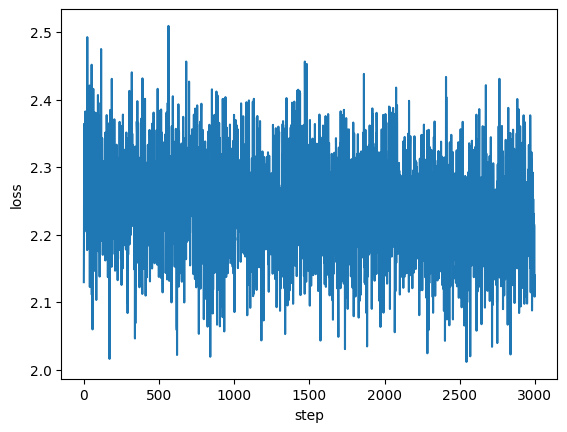

In [209]:
# learning about correct learning rate
losses = []
for i in range(3000):
    idx = torch.randint(0, Xtr.shape[0], (batch_size,))
    xi = Xtr[idx].to(device)
    yi = Ytr[idx].to(device)
    logits = model(xi)
    optimizer.zero_grad()
    loss = criterion(logits.view(-1, vocab_size), yi.view(-1))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if i % 100 == 0:
        print(f"step {i} loss: {loss.item():.4f}")

plt.plot(losses)
plt.xlabel('step')
plt.ylabel('loss')
plt.show()

In [210]:
model.eval()
with torch.no_grad():
    idx = torch.randint(0, Xtr.shape[0], (batch_size,))
    xi = Xtr[idx].to(device)
    yi = Ytr[idx].to(device)
    logits = model(xi)
    dev_loss = criterion(logits.view(-1, vocab_size), yi.view(-1))
    print(f"train loss: {dev_loss.item():.4f}")
model.eval()
with torch.no_grad():
    idx = torch.randint(0, Xtr.shape[0], (batch_size,))
    xi = Xtr[idx].to(device)
    yi = Ytr[idx].to(device)
    logits = model(xi)
    dev_loss = criterion(logits.view(-1, vocab_size), yi.view(-1))
    print(f"dev loss: {dev_loss.item():.4f}")
model.train()

train loss: 2.1740
dev loss: 2.2553


AttentionModel(
  (embedding): Embedding(16490, 32, padding_idx=16489)
  (first_linear): Linear(in_features=32, out_features=256, bias=True)
  (le_relu1): LeakyReLU(negative_slope=0.01)
  (second_linear): Linear(in_features=256, out_features=256, bias=True)
  (le_relu2): LeakyReLU(negative_slope=0.01)
  (logits_linear): Linear(in_features=256, out_features=16490, bias=True)
)

In [147]:
for i in range(10):
    idx = torch.randint(0, Xtr.shape[0], (batch_size,))
    xi = Xtr[idx].to(device)  # (32, context_len)
    yi = Ytr[idx].to(device)  # (32, context_len)

    logits = model(xi)

    optimizer.zero_grad()
    loss = criterion(
        logits.view(-1, vocab_size),  # (batch*context_len, vocab_size)
        yi.view(-1)
    )
    loss.backward()
    optimizer.step()
    print("loss: ", loss.item())

loss:  9.709768295288086
loss:  9.707533836364746
loss:  9.704302787780762
loss:  9.701401710510254
loss:  9.703556060791016
loss:  9.700332641601562
loss:  9.698277473449707
loss:  9.694624900817871
loss:  9.69433879852295
loss:  9.69229793548584


In [211]:
model.eval()

def generate_stories(max_words=50):
    tokens = [start]  # start token
    
    with torch.no_grad():
        for _ in range(max_words):
            # pad to context_len
            context = tokens[-context_len:]
            padded = context + [-1] * (context_len - len(context))
            x = torch.tensor(padded).unsqueeze(0).to(device)  # (1, context_len)
            
            logits = model(x)  # (1, context_len, vocab_size)
            
            # take logits at the last real token position
            last_pos = len(context) - 1
            next_logits = logits[0, last_pos, :]  # (vocab_size,)
            
            # sample from distribution
            probs = F.softmax(next_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()
            
            if next_token == end:
                break
                
            tokens.append(next_token)
    
    words = [i_to_word[t] for t in tokens[1:]]  # skip start token
    return ' '.join(words)
for i in range(5):
    print(generate_stories(50)) 
model.train()


 The creamy , and it can count the pictures and was driving that he wanted some money . It wanted to share her favorite who could go with his cars ! " Ben , honey on it , sees the book of money about a jump out for them
Once there , were monsters . It would bake something you take the banana ! " Sam is sad . It says . Do you know more people feel special , it is the rice ! " Tom is angry to everyone bought all around looking for the paw in

 The day was a sign and a fierce result too ? Where would look at his banana when it very hungry . And you , it felt like the spider . And they waved to jump . Then he heard that belonged to your helmet . His friends cheered

 Molly thought and her pretty clothes . Grandma sighed . They cry and ask their parents if she should share her favorite food . It flew down and frown . It peered away . Then he hated playing games and angry . It reached for being a hero ,
One day a butterfly . Fuzzy nodded and sees a circle that had big sandcastle . Someone i

AttentionModel(
  (embedding): Embedding(16490, 32, padding_idx=16489)
  (first_linear): Linear(in_features=32, out_features=256, bias=True)
  (le_relu1): LeakyReLU(negative_slope=0.01)
  (second_linear): Linear(in_features=256, out_features=256, bias=True)
  (le_relu2): LeakyReLU(negative_slope=0.01)
  (logits_linear): Linear(in_features=256, out_features=16490, bias=True)
)

In [212]:
torch.save(model.state_dict(), 'model_weights.pth')